# Use case 3 - Flooding in Zuid-Holland

In [1]:
# HIDE CODE
# Imports
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx

from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema
from config import get_config, get_development_config, setup_dev_directories, get_simulation_params
from src.simulation import simulate_asset_damage_recovery_access_breakdown 
from src.dependency_knowledge_graph import build_default_knowledge_graph
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.caching import load_simulation_caches
from pathlib import Path
from src.impacts import (
    create_voronoi_for_asset_type, prepare_population_impact_data,
    prepare_land_use_impact_data, update_voll_rates,
    prepare_population_impact_data_multigroup,
    calculate_societal_access_impacts,
    create_voronoi_boundary,
)
import pickle
from src.visualisations import *
from ema_workbench import Model, RealParameter, IntegerParameter, Constant, TimeSeriesOutcome, SequentialEvaluator, Samplers, ema_logging, Policy

c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


## General Comments
Note: Hazard, exposure, population, and land use data are too heavy. A sample of the data is provided instead.




## Introduction 

- Using pluvial flood data for South Holland, in the Netherlands, we estimate the disruptions on medium-low voltage substations, considering a set number of repair crews to carry out repairs on broken down substations. We availability of the road network is used to determine whether a substation can be reached.

- This use case is most relevant for electricity distribution network operators

- The focus of this use case is adaptation under uncertainty in interdependent CI


## Directory structure 


In [2]:
# Set up configuration
config = get_development_config() #get_config() gets parameters directly from config.py in root, development config uses sample data
# config = get_config()
setup_dev_directories(config, remove_cache=False) # For a clean run, set remove_cache=True to clear all caches and start fresh
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']

# Configure simulation parameters from config
simulation_params = get_simulation_params(config) 
accessibility_model = None
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")

# 6 for full data, 24 for sample data (which has 24 timesteps per day instead of 4)
config['simulation_config']['major_timestep'] = 24
# config['simulation_config']['major_timestep'] = 6
config['simulation_config']['verbose'] = False

# Use the graph-aware dependency entry point for non-road assets. Road
# availability remains governed by the existing exposure-filtered road graph.
knowledge_graph = build_default_knowledge_graph()
config['dependency_parameters']['knowledge_graph'] = knowledge_graph.to_config()
max_days = None

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

root_dir = Path(config['root_dir'])
study_area_path = root_dir / 'data' / 'utilities' / 'stedin_area.geojson'
land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1_sample.gpkg'
# land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1_sample.gpkg"
# population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1.gpkg"

print(f"WARNING! Values of lost load should be calculated with country-wide VOLL rates, not sample data!")

# Cache path for asset_to_lu (the complete pre-computed lookup)
asset_to_lu_cache_path = config['interim_dir'] / f"{land_use_path.stem}_asset_to_lu.pkl"

Created directories: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps, c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps

Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  recovery_parameters: {'repair_time_coefficients': [702.72, 3.14, 1.9891], 'damage_ratio_coefficients': (0.0468, 0.0077), 'fragility_models': {}, 'damage_threshold': 0.01, 'repair_threshold': 2.0}
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps
Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
Loaded hazard extraction cache: 20 entries fr

## Hazard characterisation 

Data description - Pluvial flooding

The flood considered in this use case is produced by excess rainfall. 
To produce this data, the assumption of 200 mm of rainfall on previously wet soil over the whole province of South Holland, the Netherlands was considered. 

The data consists of time explicity flooding depth maps at a daily timestep. The aggregated flood maps for this model can be found in the Open Data Portal of Zuid Holland: https://opendata.zuid-holland.nl/geonetwork/srv/api/records/6cb97102-f3b3-421e-a37e-c90615118e6d

While this case considers a single hazard type (pluvial flooding), it looks into consecutive days of flooding with the cascading effects of disrupted roads on the electricity network repairs.


Found 10 hazard map files


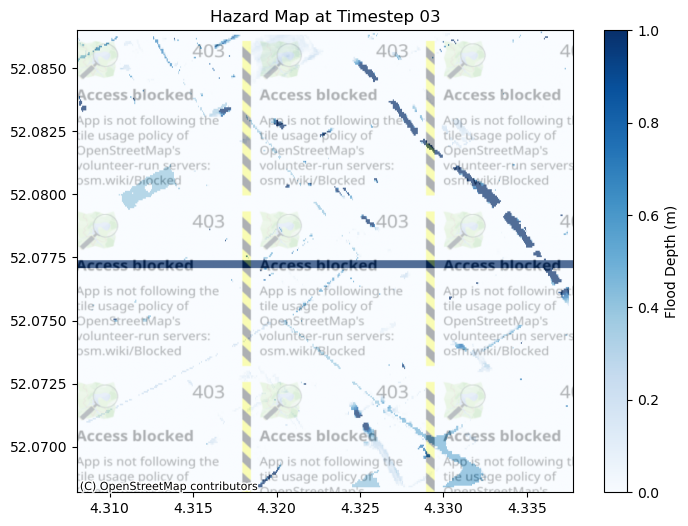

In [3]:
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  
hazard_map_03 = hazard_maps[3]
with rasterio.open(hazard_map_03) as src:
    hazard_data_03 = src.read(1)
    hazard_transform_03  = src.transform
    crs = src.crs


from rasterio.plot import plotting_extent

fig, ax = plt.subplots(figsize=(8, 6))
extent = plotting_extent(hazard_data_03, hazard_transform_03)
im = ax.imshow(hazard_data_03, cmap='Blues', vmax=1, extent=extent, origin='upper', zorder=1)
ax.set_title("Hazard Map at Timestep 03")
fig.colorbar(im, ax=ax, label="Flood Depth (m)")

# Set axis to Web Mercator for contextily
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_aspect('auto')
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.3,zorder=2)
plt.show()

## Exposure Assessment

The electricity substation data is provided by Stedin, the local DSO, openly. 
The street data used is retrieved from OpenStreetMap


Found 1 electricity station files matching types ['msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['msls_stations_test_samples.shp']
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 245 electricity assets
Asset types: {'msls': 245}


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10820\1530913130.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green',


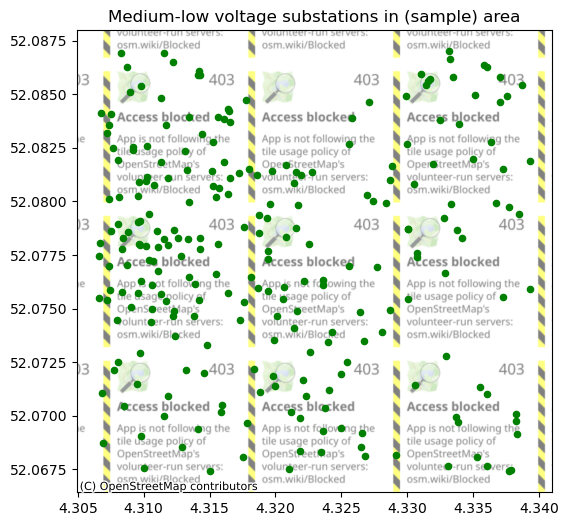

In [4]:
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])
fig, ax = plt.subplots(figsize=(8, 6))
gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green', 
                                        #    markersize=2)
                                          markersize=20)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.5)
plt.title("Medium-low voltage substations in (sample) area")
plt.show()

## Vulnerability Assessment 

We estimate the damage to substations by intersecting the footprints of the substations with flooding depth data and taking the maximum value. 

This value is then related to substation damage using a linearized depth-damage (vulnerability) curve (FEMA, 2003; Sánchez-Muñoz et al., 2020). Substation damage is expressed as a damage ratio between 0 (undamaged) and 1 (fully damaged). Finally, the damage ratio is used to estimate the repair time in hours through a repair time function (Movahednia et al., 2022; Sánchez-Muñoz et al., 2020).
 
 FEMA. Multi-Hazard Loss Estimation Methodology, Flood Model: Hazus-MH MR4 Technical Manual, 2009th ed.; FEMA: Washington, DC, USA, 2009.
 
 Movahednia, M., Kargarian, A., Ozdemir, C. E., & Hagen, S. C. (2022). Power Grid Resilience Enhancement via Protecting Electrical Substations Against Flood Hazards: A Stochastic Framework. IEEE Transactions on Industrial Informatics, 18(3), 2132–2143. https://doi.org/10.1109/TII.2021.3100079

 Sánchez-Muñoz, D., Domínguez-García, J. L., Martínez-Gomariz, E., Russo, B., Stevens, J., & Pardo, M. (2020). Electrical Grid Risk Assessment Against Flooding in Barcelona and Bristol Cities. Sustainability, 12(4), 1527. https://doi.org/10.3390/su12041527


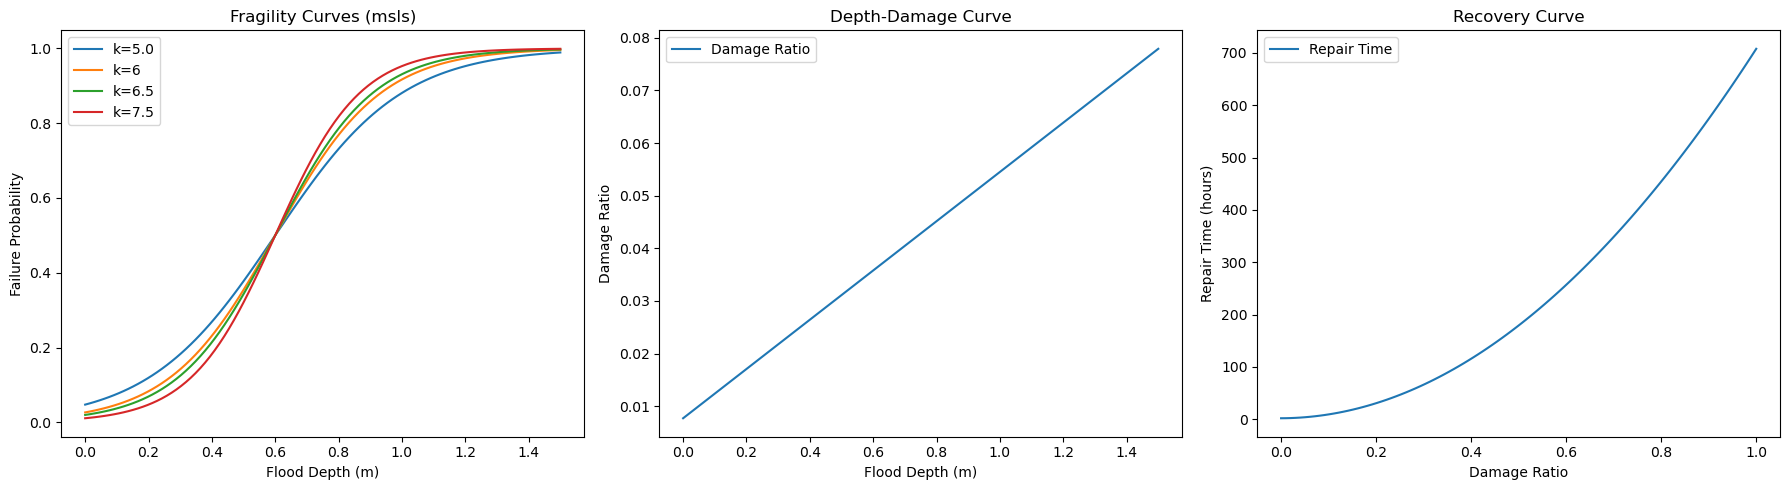

In [5]:
import numpy as np

import matplotlib.pyplot as plt
from src.damage_recovery import (
    default_damage_ratio_function,
    default_repair_time_function,
    vectorized_damage_ratio_solver,
    default_fragility_function,
)

# Example coefficients for curves
damage_coeffs = simulation_params['recovery_parameters']['damage_ratio_coefficients']  # m, n for damage ratio
repair_coeffs = simulation_params['recovery_parameters']['repair_time_coefficients']  # a, b, c for repair time

hazard_depths = np.linspace(0, 1.5, 100)
damage_ratios = default_damage_ratio_function(hazard_depths, damage_coeffs)
damage_ratios = np.clip(damage_ratios, 0, 1)  # Ensure damage ratio does not exceed 1

# Recovery functions in range [0, 1]
damage_ratios_recovery = np.linspace(0, 1, 100)
repair_times = default_repair_time_function(damage_ratios_recovery, repair_coeffs)

# Fragility curves for different positive slopes
slopes = [5.0, 6, 6.5, 7.5]
fragility_curves = {
    k: 1 / (1 + np.exp(-k * (hazard_depths - 0.6)))
    for k in slopes
}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Fragility curves with multiple slopes
for k, curve in fragility_curves.items():
    axs[0].plot(hazard_depths, curve, label=f'k={k}')
axs[0].set_title('Fragility Curves (msls)')
axs[0].set_xlabel('Flood Depth (m)')
axs[0].set_ylabel('Failure Probability')
axs[0].legend()

# 2. Depth-Damage curve
axs[1].plot(hazard_depths, damage_ratios, label='Damage Ratio')
axs[1].set_title('Depth-Damage Curve')
axs[1].set_xlabel('Flood Depth (m)')
axs[1].set_ylabel('Damage Ratio')
axs[1].legend()

# 3. Recovery curve in [0,1]
axs[2].plot(damage_ratios_recovery, repair_times, label='Repair Time')
axs[2].set_title('Recovery Curve')
axs[2].set_xlabel('Damage Ratio')
axs[2].set_ylabel('Repair Time (hours)')
axs[2].legend()

plt.tight_layout()
plt.show()

## Risk Assessment 

The time explicit breakdown and recovery simulation is done iteratively to explore the uncertainty space, with all the deterministic results (e.g. flood overlays, road isolations, etc) being computed once, and catched for future runs. 

### A single simulation is not enough

The results from a single simulation give some indication of the stations that get flooded, the duration of the flood, and the extent of the damage. Here we set the slope of the fragility curve at 6.0, and assume there are 5 repair crews available for the area

In [6]:
all_results, final_state, cache_updated = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets,
    hazard_maps,
    number_repair_crews = 5,
    repair_crew_assignment_method = simulation_params['repair_crew_assignment_method'],
    flood_threshold = simulation_params['flood_threshold'],
    recovery_parameters = simulation_params['recovery_parameters'],
    root_dir = config['root_dir'],
    verbose = False,
    timestep_output=True,
    execution_id = "test_run_breakdown",
    config=config,
    major_timestep=config['simulation_config']['major_timestep'],
    accessibility_cache=caches.get('accessibility_cache', None),
    hazard_extraction_cache=caches.get('hazard_extraction_cache', None),
    overlap_cache=caches.get('overlap_cache', None),
    island_cache=caches.get('island_cache', None), 
    fragility_param_k=6.0
)
print(f"\nSimulation completed. Cache updated")


Simulation completed. Cache updated


In [7]:
results_df_x=pd.DataFrame(all_results[0][1])
print_simulation_summary(results_df_x, gdf_assets, config)

SIMULATION RESULTS SUMMARY
Total assets: 245
Simulation duration: 240 hours (10 days)
Final operational rate: 100.0%
Peak damaged assets: 11
Peak flooded assets: 11
Total crew assignments: 61

RECOVERY TIMELINE (Daily Summary)
Day 0: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 1: 96.3% operational, 9 flooded, 0 unreachable, 9 damaged.
Day 2: 95.5% operational, 11 flooded, 0 unreachable, 11 damaged.
Day 3: 95.5% operational, 11 flooded, 0 unreachable, 11 damaged.
Day 4: 96.3% operational, 9 flooded, 0 unreachable, 9 damaged.
Day 5: 97.6% operational, 6 flooded, 0 unreachable, 6 damaged.
Day 6: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 7: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 8: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 9: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.

REPAIR BACKLOG ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
-----------------------------------------------------

To understand the extent of the impact, it is necessary to map the population and the value of lost load to each substations. In other words, when a substation fails, it is necessary to understand how many people live in the area it services, and the economic activity that takes place in the area. 

For that, population and land-use information can be of use. The Central Bureau voor de Statistiek (CBS) of the Netherlands provides this information - https://www.cbs.nl/en-gb

First, the population data is mapped to service areas:

```{note}
In this case, a sample of the data is used. Please note that for monetary impacts to be relevant, the country-scale land-use data should be used; when the country-scale data is used, this computation can take several minutes. 
```

In [8]:


study_area = gpd.read_file(study_area_path, driver='GeoJSON').to_crs("EPSG:28992")

buffer_distance_meters = 1000
population_buffer = study_area.buffer(buffer_distance_meters)
population_buffer.set_crs("EPSG:28992")

# Create Voronoi polygons for service areas
print("Creating Voronoi polygons for service areas...")
voronoi_polygons_by_type = {}
for asset_type in gdf_assets['type'].unique():
    voronoi_gdf = create_voronoi_for_asset_type(
        gdf_assets, 
        asset_type, 
        boundary=study_area.geometry.unary_union
    )
    voronoi_polygons_by_type[asset_type] = voronoi_gdf

# Load and prepare population data
print("Loading population data...")
population_data = gpd.read_file(
    population_data_path,
    driver='GPKG',
    bbox=tuple(voronoi_gdf.total_bounds)
).to_crs("EPSG:28992")

# Filter out zero population and invalid geometries
population_data = population_data[
    (population_data['aantal_inwoners'] > 0) & 
    (~population_data.geometry.isna())
].dropna(subset=['geometry'])

# Clip to study area
population_study_area = gpd.clip(population_data, population_buffer)
groups_to_keep = ['aantal_inwoners', 'aantal_inwoners_65_jaar_en_ouder', 'aantal_inwoners_0_tot_15_jaar']
population_above_0 = population_study_area[groups_to_keep + ['geometry']].set_crs("EPSG:28992")

# Make negative population values zero for all groups to keep
for col in groups_to_keep:
    population_above_0[col] = population_above_0[col].clip(lower=0)

# Prepare population impact mapping
print("Preparing population impact data...")
asset_population_map = prepare_population_impact_data(
    population_data=population_above_0,
    voronoi_gdf=voronoi_polygons_by_type['msls']
)
print(f"Population data prepared for {len(asset_population_map)} assets")

voronoi_gdf['pop_map'] = [asset_population_map[x] for x in voronoi_gdf['asset_id']]


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(
C:\Users\peregrin\AppData\Local\Temp\ipykernel_10820\4205631368.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary=study_area.geometry.unary_union


Creating Voronoi polygons for service areas...
Loading population data...


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


Preparing population impact data...
Population assignment: 221/229 polygons with impact values
Total assigned population: 41969
Population data prepared for 229 assets


Then, the same is done for Values of Lost Load per land use:

In [9]:
# Try to load pre-computed asset_to_lu
if asset_to_lu_cache_path.exists():
    print(f"Loading asset_to_lu from cache: {asset_to_lu_cache_path}")
    with open(asset_to_lu_cache_path, 'rb') as f:
        asset_to_lu = pickle.load(f)
    print(f"Loaded asset_to_lu for {len(asset_to_lu)} assets from cache")

    asset_land_use_map = {
        aid: {lu_type: area for lu_type, area, voll_rate in lu_entries}
        for aid, lu_entries in asset_to_lu.items()
    }
    
else:
    print("Computing asset_to_lu from scratch...")
       
    # Load land use data
    land_use_data = gpd.read_file(land_use_path, driver='GPKG')
    
    # Calculate VOLL rates (populates VOLL_PER_SQM)
    consumption_per_sqm, voll_per_sqm = update_voll_rates(land_use_data)
    print(f"VOLL rates calculated for {len(voll_per_sqm)} categories")
    
    # Compute asset-land use intersections (the expensive operation)
    asset_land_use_map = prepare_land_use_impact_data(
        land_use_data, 
        voronoi_gdf=voronoi_polygons_by_type['msls']
    )
    print(f"Computed intersections for {len(asset_land_use_map)} assets")
    
    # Build asset_to_lu with VOLL rates included
    asset_to_lu = {}
    for aid, lu_dict in asset_land_use_map.items():
        asset_to_lu[aid] = [(lu_type, area, voll_per_sqm[lu_type]) 
                             for lu_type, area in lu_dict.items() 
                             if lu_type in voll_per_sqm]
    
    # Cache the complete lookup
    with open(asset_to_lu_cache_path, 'wb') as f:
        pickle.dump(asset_to_lu, f)
    print(f"Saved asset_to_lu to cache: {asset_to_lu_cache_path}")

# Output
print(f"\nasset_to_lu ready with {len(asset_to_lu)} assets")


Loading asset_to_lu from cache: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\CBS_Publicatiebestand_BBG2017_v1_sample_asset_to_lu.pkl
Loaded asset_to_lu for 229 assets from cache

asset_to_lu ready with 229 assets


Now we visualise the data (sample area visualised)


Land Use Visualization Statistics:
  Total voronoi polygons: 229
  Assets with land use data: 227
  Assets without land use data: 2
  Assets not in mapping: 0
  Total in asset_land_use_map: 229


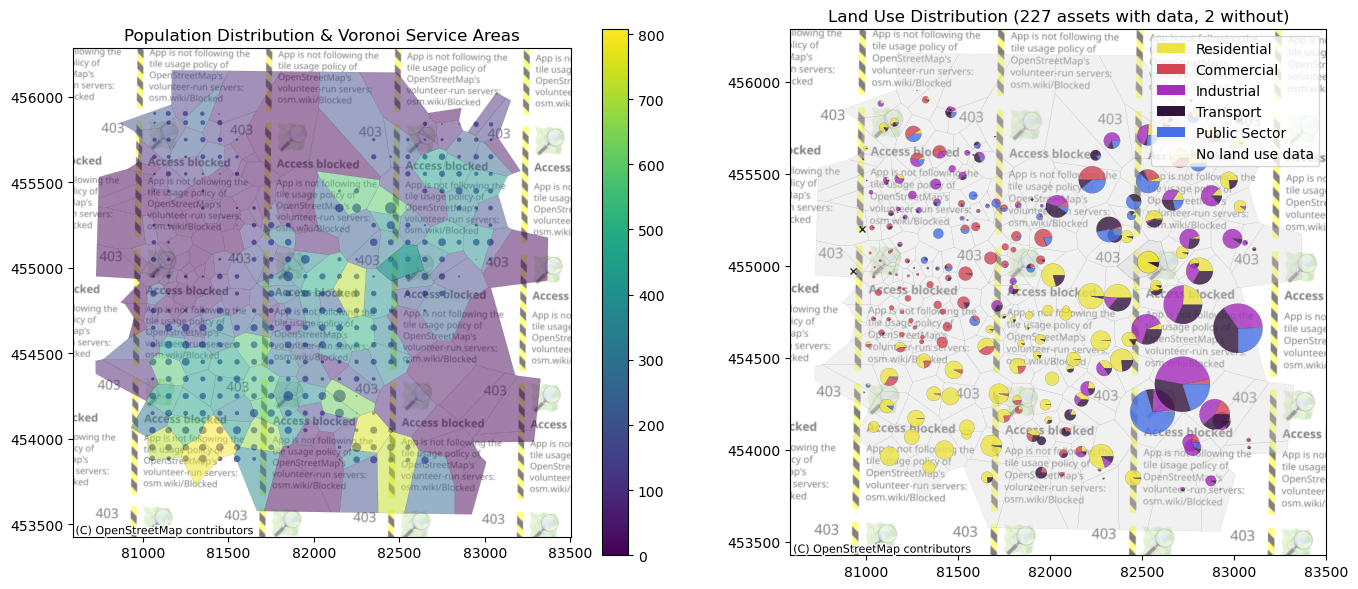

In [10]:
plot_population_and_landuse(
    population_above_0,
    sizes=population_above_0['aantal_inwoners'] / 10,
    voronoi_gdf=voronoi_gdf,
    gdf_assets=gdf_assets,
    asset_land_use_map=asset_land_use_map,
)

voronoi_gdf.to_file(config['interim_dir'] / 'voronoi_service_areas.geojson', driver='GeoJSON')
gdf_assets.to_file(config['interim_dir'] / 'assets_with_voronoi.geojson', driver='GeoJSON')

## Societal Access Analysis

Who loses access to **electricity** and who loses access to **hospitals**?

This section generalises the population-impact calculation to multiple service
functions and demographic groups, using the helpers added to ``src/impacts.py``.

A single synthetic hospital is added at the location of the second test hospital
used in ``Use_Case_sample_knowledge_graph.ipynb``
(RD coordinate: 82526.21, 455532.75, EPSG:28992).


In [11]:
from shapely.geometry import Point
from src.utils import compile_asset_gdfs, build_voronoi_service_area_map
from src.impacts import (
    prepare_population_impact_data_multigroup,
    calculate_societal_access_impacts,
    create_voronoi_boundary,
)

# ── Synthetic hospital (second test hospital from knowledge-graph notebook) ──
# RD New (EPSG:28992) centroid: 82526.21, 455532.75; 15 m buffer polygon.
gdf_hospital = gpd.GeoDataFrame(
    {'type': ['hospital'], 'name': ['Test_Hospital']},
    geometry=[Point(82526.21, 455532.75).buffer(15)],
    crs='EPSG:28992',
).to_crs('EPSG:4326')

# Combine electricity substations + hospital into one asset GeoDataFrame
gdf_assets_combined = compile_asset_gdfs([gdf_assets, gdf_hospital])

substation_idx = list(gdf_assets_combined[gdf_assets_combined['type'] == 'msls'].index)
hospital_idx   = list(gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].index)
print(f"Combined assets: {len(gdf_assets_combined)}  "
      f"(substations: {len(substation_idx)}, hospitals: {len(hospital_idx)})")


Combined assets: 246  (substations: 245, hospitals: 1)


In [12]:
# ── Voronoi service areas and hospital ↔ substation mapping ─────────────────
boundary = create_voronoi_boundary(gdf_assets_combined[gdf_assets_combined['type'] == 'msls'])
voronoi_gdf_combined = create_voronoi_for_asset_type(gdf_assets_combined, 'msls', boundary=boundary)

gdf_hospital_proj = gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].to_crs(voronoi_gdf_combined.crs)
service_area_map, _ = build_voronoi_service_area_map(voronoi_gdf_combined, gdf_hospital_proj, return_diagnostics=True)
print("Service-area map (substation → hospitals):", service_area_map)


Service-area map (substation → hospitals): {192: [245]}


In [13]:
# ── Knowledge-graph rules: msls → hospital (power dependency) ────────────────
from src.dependency_knowledge_graph import build_default_knowledge_graph

kg = build_default_knowledge_graph()
config_combined = {**config}
config_combined['dependency_parameters'] = {
    **config['dependency_parameters'],
    'knowledge_graph': kg.to_config(),
    'service_area_map': service_area_map,
}


In [14]:
# ── Run simulation with electricity substations + hospital ───────────────────
from src.caching import load_simulation_caches

caches_combined = load_simulation_caches(config_combined['interim_dir'], config_combined['hazard_dir'])

all_results_combined, final_state_combined, _ = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets_combined,
    hazard_maps,
    number_repair_crews=5,
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=simulation_params['recovery_parameters'],
    root_dir=config_combined['root_dir'],
    verbose=False,
    timestep_output=True,
    execution_id='societal_access_run',
    config=config_combined,
    accessibility_cache=caches_combined.get('accessibility_cache'),
    hazard_extraction_cache=caches_combined.get('hazard_extraction_cache'),
    overlap_cache=caches_combined.get('overlap_cache'),
    island_cache=caches_combined.get('island_cache'),
)

# Detailed timestep outputs
timestep_results_combined = all_results_combined[0][2] if all_results_combined else []
print(f"Simulation complete: {len(timestep_results_combined)} timestep(s)")


Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
Loaded hazard extraction cache: 20 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Loaded overlap cache: 45 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Loaded island cache: 50 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\island_cache_test_hazard_timesteps.pkl
Loaded societal allocation cache: 1 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\societal_allocation_cache_test_hazard_timesteps.pkl
Identified 14 boundary assets out of 246 total assets.
Extracting hazard values using method: max
Saved hazard extraction cache: 21 entries to c:\repos\powerpath\powerpath\data\int

In [15]:
# ── Population group columns ─────────────────────────────────────────────────
# Use the taxonomy defined in config.py (service_node_config.population_groups)
pop_groups = config['service_node_config']['population_groups']
# Filter to columns present in the loaded population data
pop_groups_available = {
    label: col for label, col in pop_groups.items()
    if col in population_above_0.columns
}
print("Population groups used:", list(pop_groups_available.keys()))

# ── Build population maps for electricity substations ────────────────────────
electricity_pop_maps = prepare_population_impact_data_multigroup(
    population_data=population_above_0,
    voronoi_gdf=voronoi_gdf_combined,
    group_columns=pop_groups_available,
)
print("Electricity population maps:", {k: sum(v.values()) for k, v in electricity_pop_maps.items()})


Population groups used: ['total', 'elderly', 'children']


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10820\578411064.py:12: DeprecationWarning: prepare_population_impact_data_multigroup is deprecated for societal access workflows; prefer src.societal_access.postprocess_societal_access_results.
  electricity_pop_maps = prepare_population_impact_data_multigroup(


Population assignment: 221/229 polygons with impact values
Total assigned population: 41969
Population assignment: 192/229 polygons with impact values
Total assigned population: 4485
Population assignment: 174/229 polygons with impact values
Total assigned population: 4832
Electricity population maps: {'total': 41968.85299409766, 'elderly': 4485.226579263869, 'children': 4831.778852054285}


In [16]:
# ── Build per-asset service-function map ─────────────────────────────────────
# Map each asset to its function label based on asset type.
# Substations (msls) → 'electricity'; hospitals → 'health'
service_node_taxonomy = config['service_node_config']['taxonomy']

asset_function_map = {}
for idx, row in gdf_assets_combined.iterrows():
    asset_type = row.get('type', '')
    if asset_type in ('msls', 'ms', 'ls'):
        asset_function_map[idx] = 'electricity'
    elif asset_type in service_node_taxonomy:
        asset_function_map[idx] = service_node_taxonomy[asset_type]

# ── Build hospital population maps (Voronoi of hospitals) ────────────────────
# For hospitals we use the same Voronoi polygons of substations as service areas
# (a hospital cell is covered by whichever substation serves it).
# Hospital population maps use the same spatial assignment as electricity.
# Prefix keys with 'health:' so calculate_societal_access_impacts can split them.
health_pop_maps = {
    f'health:{label}': {
        hosp_i: pop
        for sub_i, pop_map in zip(substation_idx, [])  # placeholder — built below
        for hosp_i, pop in {}.items()
    }
    for label, col in pop_groups_available.items()
}

# Simpler: assign to hospital the population in its supplying substation's Voronoi cell
# (proxy: who can no longer reach the hospital when it is down)
hospital_pop_maps = {}
for label, col in pop_groups_available.items():
    h_pop = {}
    for sub_i, hosp_list in service_area_map.items():
        supplier_pop = electricity_pop_maps.get(label, {}).get(sub_i, 0)
        for h_i in hosp_list:
            h_pop[h_i] = supplier_pop / max(len(hosp_list), 1)
    hospital_pop_maps[f'health:{label}'] = h_pop

print("Hospital population maps:", {k: sum(v.values()) for k, v in hospital_pop_maps.items()})

# ── Merge electricity + health maps ─────────────────────────────────────────
# Use 'electricity:' prefix for electricity maps
combined_group_maps = {
    f'electricity:{label}': pop_map
    for label, pop_map in electricity_pop_maps.items()
}
combined_group_maps.update(hospital_pop_maps)


Hospital population maps: {'health:total': 154.98827010500472, 'health:elderly': 9.13580994665771, 'health:children': 10.070436463819984}


In [17]:
# ── Calculate societal access impacts ────────────────────────────────────────
df_access = calculate_societal_access_impacts(
    detailed_results=timestep_results_combined,
    asset_group_population_maps=combined_group_maps,
    asset_function_map=asset_function_map,
)

# Pivot for a concise summary per timestep × function × group
if not df_access.empty:
    summary = df_access.pivot_table(
        index=['timestep', 'function'],
        columns='group',
        values='affected_population',
        aggfunc='sum',
    ).reset_index()
    print("\nAffected population by timestep / function / demographic group:")
    print(summary.to_string(index=False))
else:
    print("No access impact data computed.")



Affected population by timestep / function / demographic group:
 timestep    function   children    elderly       total
        0 electricity   0.000000   0.000000    0.000000
        0      health   0.000000   0.000000    0.000000
        1 electricity   0.000000   0.000000    0.000000
        1      health   0.000000   0.000000    0.000000
        2 electricity   0.000000   0.000000    0.000000
        2      health   0.000000   0.000000    0.000000
        3 electricity   0.000000   0.000000    0.000000
        3      health   0.000000   0.000000    0.000000
        4 electricity   0.000000   0.000000    0.000000
        4      health   0.000000   0.000000    0.000000
        5 electricity   0.000000   0.000000    0.000000
        5      health   0.000000   0.000000    0.000000
        6 electricity   0.000000   0.000000    0.000000
        6      health   0.000000   0.000000    0.000000
        7 electricity   0.000000   0.000000    0.000000
        7      health   0.000000   0.00

C:\Users\peregrin\AppData\Local\Temp\ipykernel_10820\4042586615.py:2: DeprecationWarning: calculate_societal_access_impacts is deprecated; prefer src.societal_access.postprocess_societal_access_results for canonical societal metrics.
  df_access = calculate_societal_access_impacts(


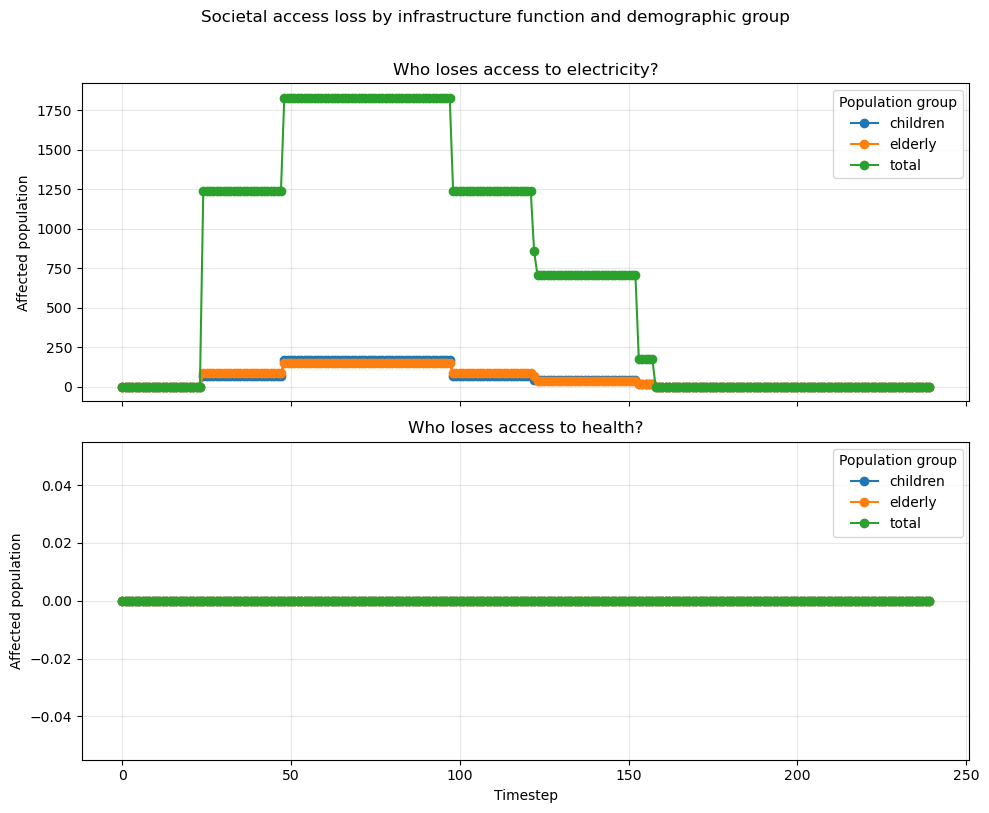

In [18]:
# ── Visualise: affected population over time by function and group ────────────
if not df_access.empty:
    functions = df_access['function'].unique()
    groups = df_access['group'].unique()
    fig, axes = plt.subplots(len(functions), 1, figsize=(10, 4 * len(functions)), sharex=True)
    if len(functions) == 1:
        axes = [axes]

    for ax, func in zip(axes, sorted(functions)):
        subset = df_access[df_access['function'] == func]
        for grp in sorted(groups):
            g = subset[subset['group'] == grp]
            ax.plot(g['timestep'], g['affected_population'], marker='o', label=grp)
        ax.set_ylabel('Affected population')
        ax.set_title(f'Who loses access to {func}?')
        ax.legend(title='Population group')
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Timestep')
    plt.suptitle('Societal access loss by infrastructure function and demographic group',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


## Adaptation

There are multiple uncertainty sources that should be accounted for: 
- How many repair crews are there actually available? 
- What is the maintenance condition of the substations and how does that affect their probability of breakdown? 
- And perhaps most importantly, what adaptation measures can we adopt in this case?

As an operational measure, different repair schemes are considered, for example, prioritising repairs for substations that service the most population, or those that service the areas of highest monetary impacts. 

We identify two structural adaptation options:
- Elevating substations
- Increasing drainage for certain areas to reduce the inundation depth

In both cases, the depth of water that the adaptation measure reduces is subtracted from the affected assets. In the case of increasing drainage, the effect on both, substations and roads is considered.

We use the Exploratory Modelling Analysis (EMA) workbench for this process: https://github.com/quaquel/EMAworkbench

 Kwakkel, J. H. (2017). The Exploratory Modeling Workbench: An open source toolkit for exploratory modeling, scenario discovery, and (multi-objective) robust decision making. Environmental Modelling & Software, 96, 239–250. https://doi.org/10.1016/j.envsoft.2017.06.054



```{Important}
The 'simulate_asset_damage_recovery_access_breakdown_ema' function is a wrapper for the 'simulate_asset_damage_recovery_access_breakdown' function used in the single assessment run earlier. It is designed to be passed as the function keyword argument for the Model class of the EMA workbench as shown below.

For this cell, expect long runtimes for large number of scenarios.
```

In [19]:
ema_logging.log_to_stderr(ema_logging.INFO)

# Load caches
caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

max_days = None
execution_id = int(time.time())

# Set up EMA model
model = Model('ElectricitySimulation', function=simulate_asset_damage_recovery_access_breakdown_ema)

model.uncertainties = [
    IntegerParameter('number_repair_crews', 1, 5),
    RealParameter('fragility_param_k', 5.0, 7.5)
]

keep_3d_vars = []  # No per-asset arrays
keep_2d_vars = ['flooded', 'operational', 'damage_ratio', 'repair_time']  # Aggregated

model.constants = [
    Constant('flood_threshold', 0.2),
    Constant('gdf_assets', gdf_assets),
    Constant('hazard_maps', hazard_maps[:max_days]),
    Constant('recovery_parameters', config['recovery_parameters']),
    Constant('root_dir', config['root_dir']),
    Constant('verbose', False),
    Constant('timestep_output', True),
    Constant('execution_id', execution_id),
    Constant('config', config),
    Constant('major_timestep', 24),
    # Cache parameters
    Constant('accessibility_cache', caches.get('accessibility_cache')),
    Constant('hazard_extraction_cache', caches.get('hazard_extraction_cache')),
    Constant('overlap_cache', caches.get('overlap_cache')),
    Constant('island_cache', caches.get('island_cache')),
    # Impact data
    Constant('asset_population_map', asset_population_map),
    Constant('asset_to_lu', asset_to_lu),
    # Dimensionality control 
    Constant('keep_3d_vars', []),  # 
    Constant('keep_2d_vars', ['flooded', 'operational', 'damage_ratio', 'repair_time']) 
]



# Build outcomes list
outcomes_list = []

# Add 3D outcomes (none in this case)
for var in keep_3d_vars:
    outcomes_list.append(TimeSeriesOutcome(var))

# Add 2D outcomes (aggregated across assets)
for var in keep_2d_vars:
    outcomes_list.append(TimeSeriesOutcome(var))

# Add mandatory 1D outcomes (always present)
outcomes_list.extend([
    TimeSeriesOutcome('timesteps'),
    # Population impact outcomes
    TimeSeriesOutcome('affected_population'),
    TimeSeriesOutcome('served_population'),
    TimeSeriesOutcome('affected_population_ratio'),
    # Monetary impacts
    TimeSeriesOutcome('monetary_impact_total'),
    TimeSeriesOutcome('monetary_impact_residential'),
    TimeSeriesOutcome('monetary_impact_commercial'),
    TimeSeriesOutcome('monetary_impact_industrial'),
    TimeSeriesOutcome('monetary_impact_transport'),
    TimeSeriesOutcome('monetary_impact_public_sector'),
])

model.outcomes = outcomes_list

# Set up policies
# l1_pumping_area = root_dir / 'data' / 'test_samples' / 'adaptation' / 'l1_adapt_polygon.geojson'
l1_pumping_area = root_dir / 'data' / 'test_samples' / 'adaptation' / 'L1_peilgeb_policies_separate' / 'policy_L1_area_population_top30_red_0.4.geojson'

# l2_asset_barriers = root_dir / 'data' / 'test_samples' / 'adaptation' / 'l2_adapt_polygon.geojson'
l2_asset_barriers = root_dir / 'data' / 'test_samples' / 'adaptation' / 'L2_asset_barriers' / 'mon_subs_top30_1.0m.geojson'



policies = [
    Policy('population_impacts_policy', repair_crew_assignment_method='population impacts islands'),
    Policy('monetary_impacts_policy', repair_crew_assignment_method='monetary impacts islands'),    
    Policy('lowest_repair_time_islands_policy', repair_crew_assignment_method='lowest repair time islands'),
    Policy('highest_repair_time_islands_policy', repair_crew_assignment_method='highest repair time islands'),
    
    # Adaptation - active timesteps are optional, if not provided, the adaptation is applied throughout the simulation
    Policy('baseline', 
           repair_crew_assignment_method='monetary impacts islands'),
    
    Policy('L1_area_pumping + monetary', 
           repair_crew_assignment_method='monetary impacts islands',
           l1_area_geojson=str(l1_pumping_area),
            ),
        #    l1_active_timesteps=list(range(24, 165))),
    
    Policy('L2_asset_protection + monetary',
           repair_crew_assignment_method='monetary impacts islands',
           l2_asset_geojson=str(l2_asset_barriers),
            ),
        #    l2_active_timesteps=list(range(0, 240))),
    
    Policy('L1_and_L2_combined + monetary',
           repair_crew_assignment_method='monetary impacts islands',
           l1_area_geojson=str(l1_pumping_area),
        #    l1_active_timesteps=list(range(24, 165)),
           l2_asset_geojson=str(l2_asset_barriers),
            ),
        #    l2_active_timesteps=list(range(0, 240))),
]

with SequentialEvaluator(model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(
        scenarios=50,
        policies=policies,
        uncertainty_sampling=Samplers.LHS
    )
    
experiments_df = pd.DataFrame(experiments)
print(f"\nCompleted all experiments with execution id {execution_id}. Total runs: {len(experiments)}")

[MainProcess/INFO] performing 50 scenarios * 8 policies * 1 model(s) = 400 experiments


Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
Loaded hazard extraction cache: 30 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Loaded overlap cache: 54 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Loaded island cache: 60 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\island_cache_test_hazard_timesteps.pkl
Loaded societal allocation cache: 1 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\societal_allocation_cache_test_hazard_timesteps.pkl
Loaded caches: ['accessibility_cache', 'hazard_extraction_cache', 'overlap_cache', 'island_cache', 'societal_allocation_cache']


100%|████████████████████████████████████████| 400/400 [02:02<00:00,  3.26it/s]
[MainProcess/INFO] experiments finished



Completed all experiments with execution id 1790064928. Total runs: 400


And then we visualise the results

In [20]:
experiments_df.sort_values(by=['policy', 'scenario'], inplace=True)
print(f"Sample of experiment DataFrame:")
experiments_df.sample(10).sort_index()

Sample of experiment DataFrame:


,fragility_param_k,number_repair_crews,scenario,policy,model
193,6.809639,1,43,highest_repair_time_islands_policy,ElectricitySimulation
202,6.908700,5,2,baseline,ElectricitySimulation
206,6.035200,1,6,baseline,ElectricitySimulation
208,5.021738,5,8,baseline,ElectricitySimulation
275,5.792186,3,25,L1_area_pumping + monetary,ElectricitySimulation
308,5.021738,5,8,L2_asset_protection + monetary,ElectricitySimulation
313,7.200473,4,13,L2_asset_protection + monetary,ElectricitySimulation
330,6.277083,1,30,L2_asset_protection + monetary,ElectricitySimulation
354,7.252907,1,4,L1_and_L2_combined + monetary,ElectricitySimulation
388,7.093128,3,38,L1_and_L2_combined + monetary,ElectricitySimulation


## Comparison of adaptation options

Here we can see the summary of results for the runs, and the effect each adaptation policy has on the outcomes.

In [21]:
available_outcomes = list(outcomes.keys())

# Categorize outcomes
asset_outcomes_3d = keep_3d_vars  
asset_outcomes_2d = keep_2d_vars  
population_outcomes = ['affected_population', 'served_population']
monetary_outcomes = ['monetary_impact_total', 'monetary_impact_residential', 
                    'monetary_impact_commercial', 'monetary_impact_industrial',
                    'monetary_impact_transport', 'monetary_impact_public_sector']

# Select outcomes to plot
outcomes_to_show = []

# Add available asset outcomes (will be aggregated if 3D)
for outcome in asset_outcomes_3d + asset_outcomes_2d:
    if outcome in available_outcomes:
        outcomes_to_show.append(outcome)

# Add population outcomes (already 1D/2D)
for outcome in population_outcomes:
    if outcome in available_outcomes:
        outcomes_to_show.append(outcome)

# Add monetary outcomes (already 1D/2D, cumulative)
for outcome in monetary_outcomes:
    if outcome in available_outcomes:
        outcomes_to_show.append(outcome)

# Aggregate only what needs aggregation
aggregation_info = aggregate_outcomes(outcomes, outcomes_to_show)

print("\nAggregation summary:")
for key, info in aggregation_info.items():
    print(f"  {key}: {info}")



Aggregation summary:
  flooded: already 2D
  operational: already 2D
  damage_ratio: already 2D
  repair_time: already 2D
  affected_population: already 2D
  served_population: already 2D
  monetary_impact_total: already 2D
  monetary_impact_residential: already 2D
  monetary_impact_commercial: already 2D
  monetary_impact_industrial: already 2D
  monetary_impact_transport: already 2D
  monetary_impact_public_sector: already 2D


And plot it using the lines function, part of the EMA workbench

To explore the different outputs, some grouping and filtering functionalities are prepared.

```{warning}
Monetary impacts are illustrative unless calculated with country-wide VOLL rates instead of sample data!
```

c:\repos\powerpath\powerpath\src\visualisations.py:1208: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return experiments_df[mask]
c:\repos\powerpath\powerpath\src\visualisations.py:1208: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return experiments_df[mask]


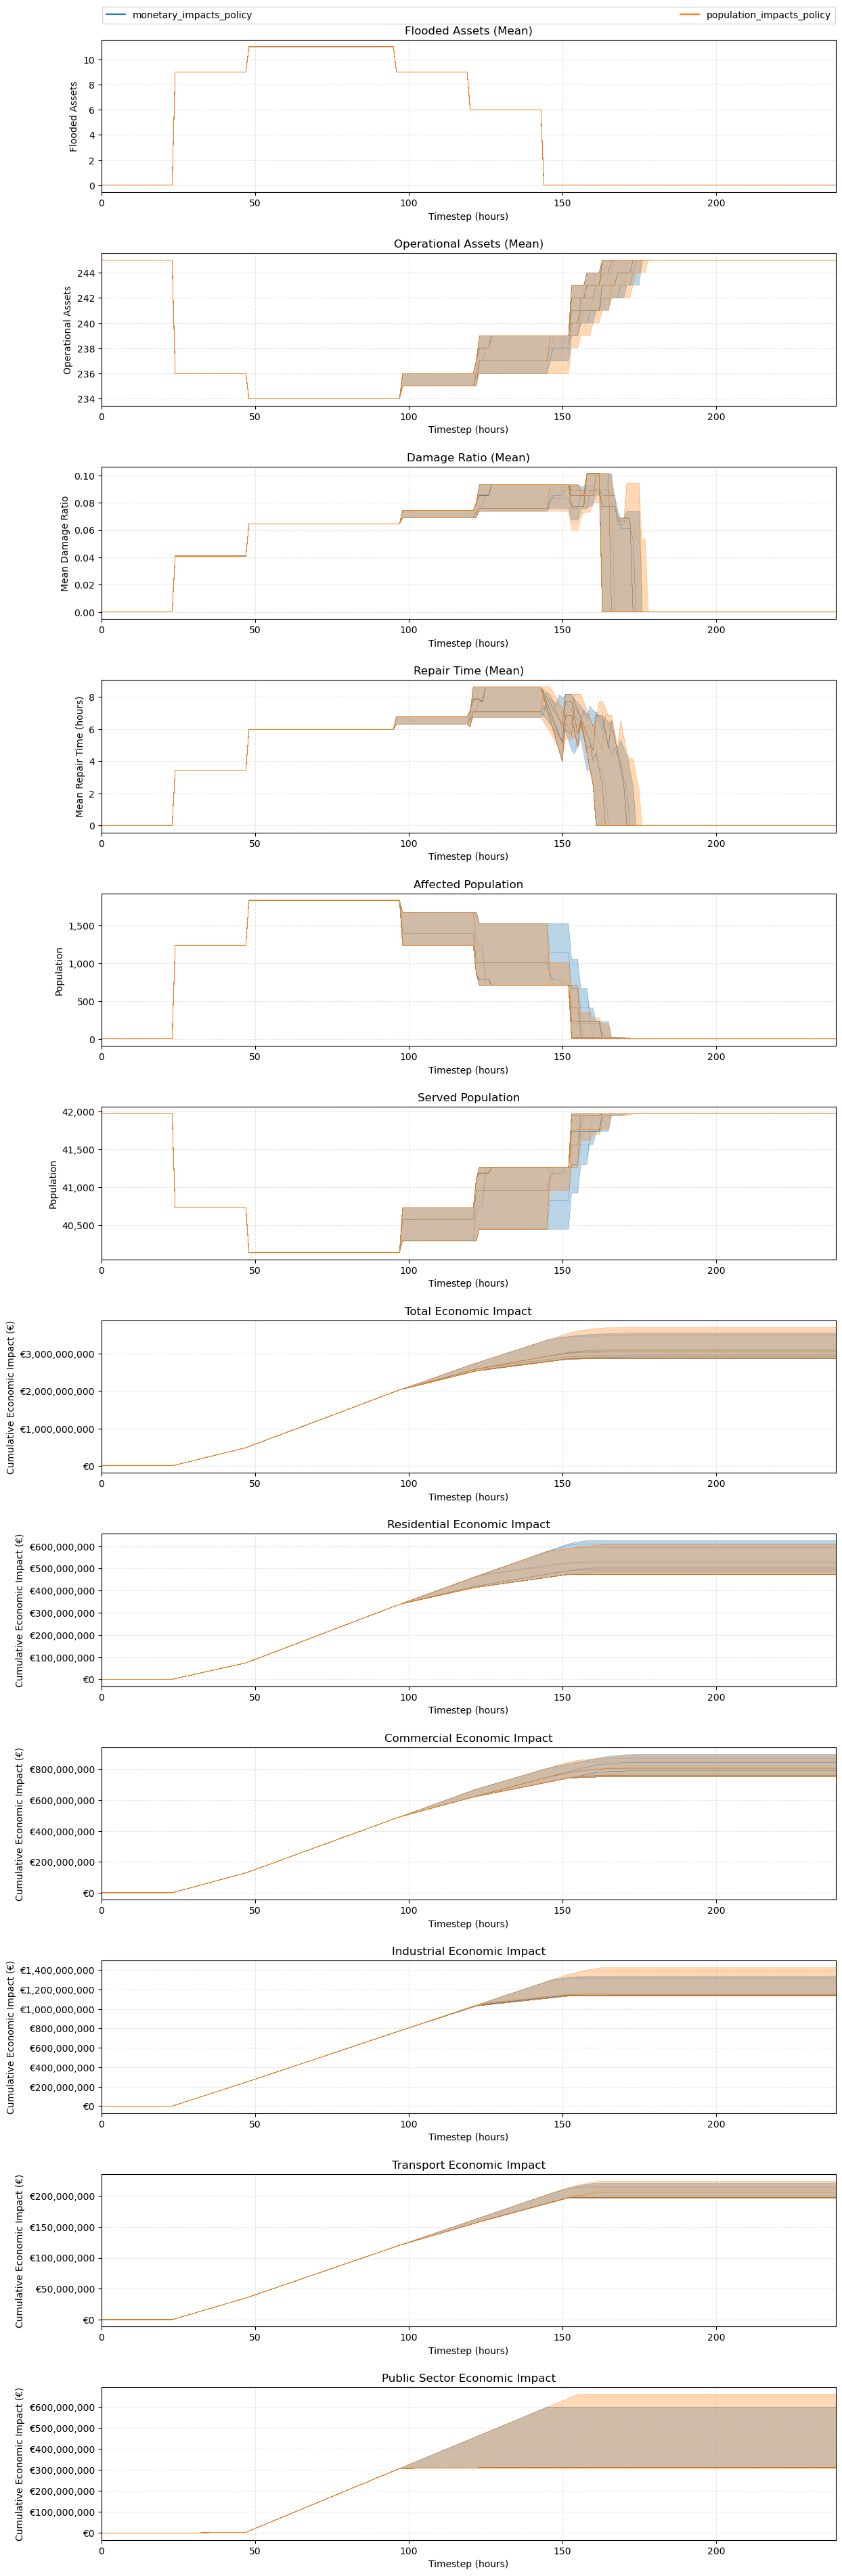



Plot summary:

Grouped by: policy
Number of bins: N/A

Outcomes plotted:
  • flooded                                  Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • operational                              Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • damage_ratio                             Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • repair_time                              Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • affected_population                      Population                     2D (400 experiments x 240 timesteps)
  • served_population                        Population                     2D (400 experiments x 240 timesteps)
  • monetary_impact_total                    Monetary (cumulative)          2D (400 experiments x 240 timesteps)
  • monetary_impact_residential              Monetary (cumulative)          2D (400 experiments x 240 timesteps)
  • monetary_impact_c

c:\repos\powerpath\powerpath\src\visualisations.py:1208: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return experiments_df[mask]
c:\repos\powerpath\powerpath\src\visualisations.py:1208: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return experiments_df[mask]


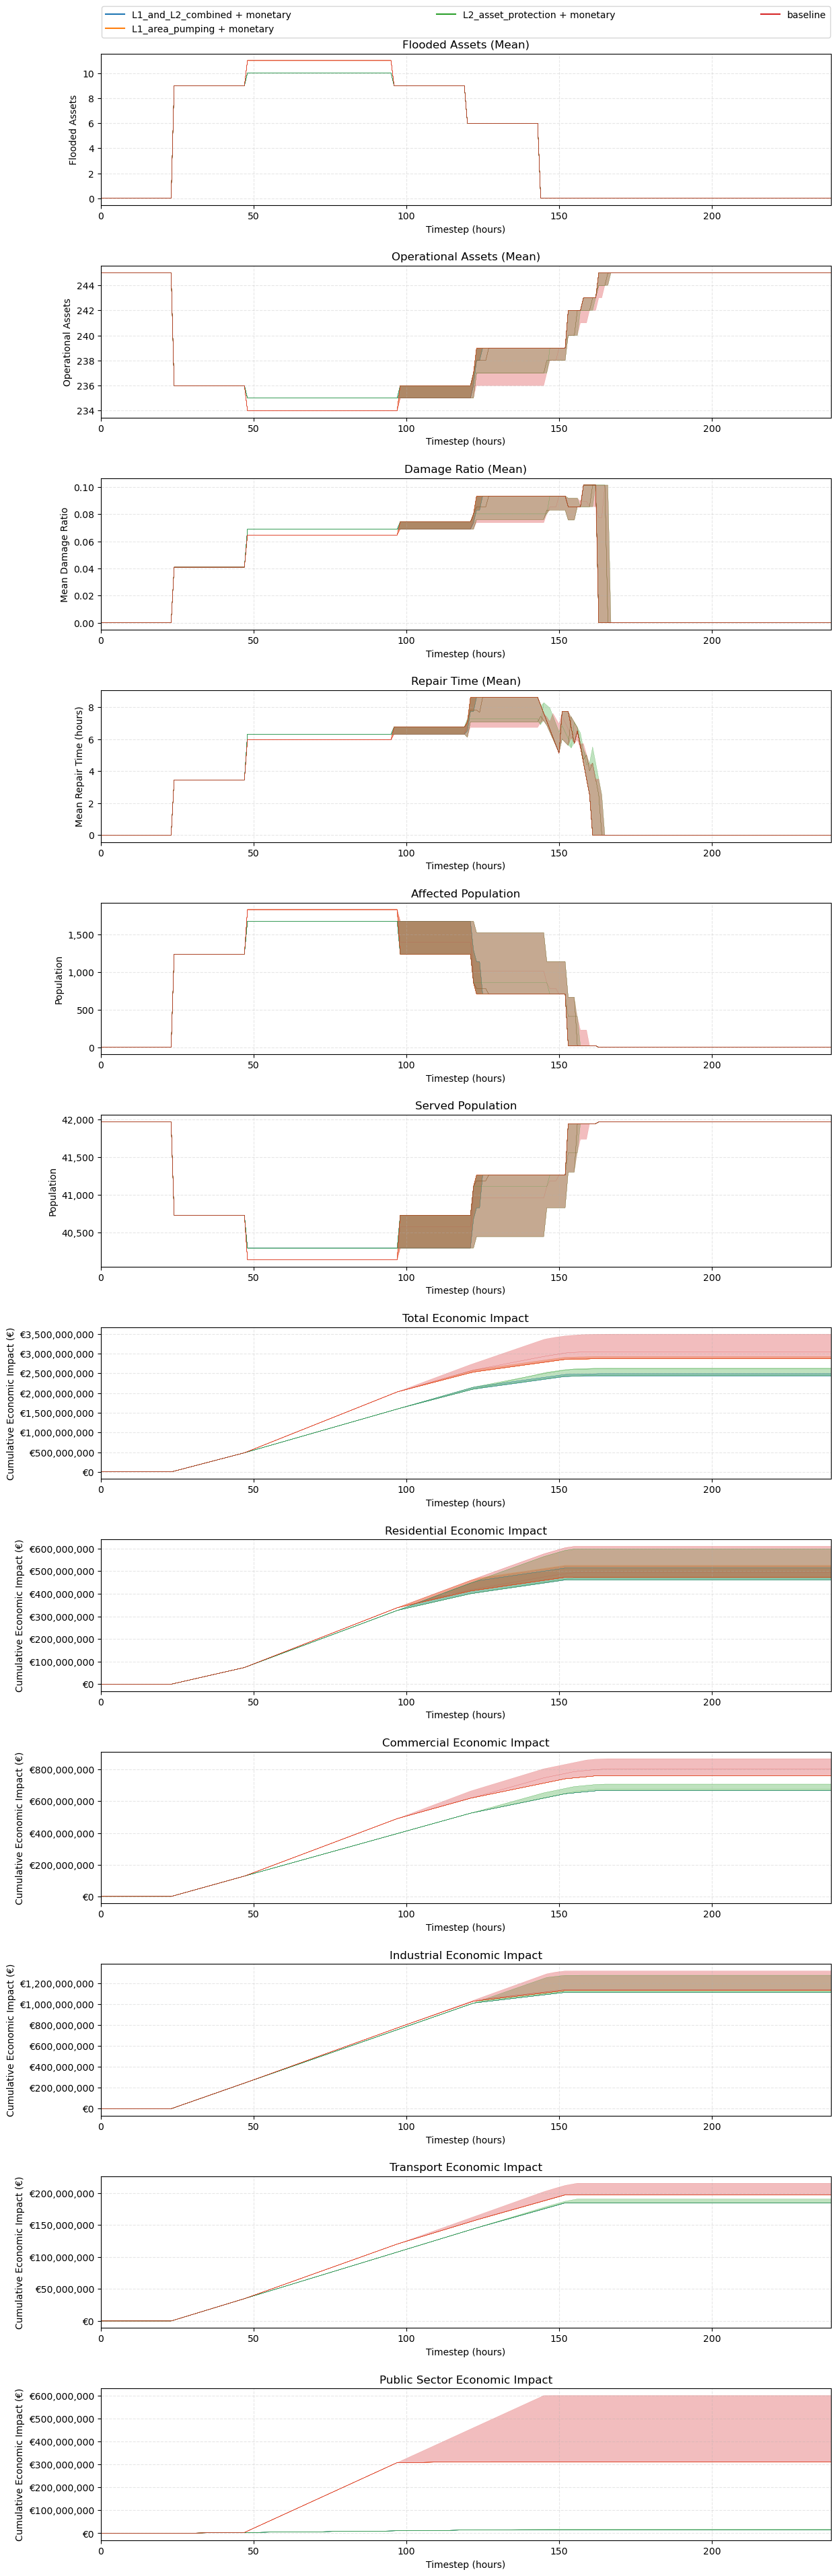



Plot summary:

Grouped by: policy
Number of bins: N/A

Outcomes plotted:
  • flooded                                  Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • operational                              Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • damage_ratio                             Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • repair_time                              Asset (2D pre-aggregated)      2D (400 experiments x 240 timesteps)
  • affected_population                      Population                     2D (400 experiments x 240 timesteps)
  • served_population                        Population                     2D (400 experiments x 240 timesteps)
  • monetary_impact_total                    Monetary (cumulative)          2D (400 experiments x 240 timesteps)
  • monetary_impact_residential              Monetary (cumulative)          2D (400 experiments x 240 timesteps)
  • monetary_impact_c

In [22]:

# Configure grouping
group_by = "policy"
# Alternative groupings (uncomment to use):

# group_by = "number_repair_crews"
# bin_ranges = [(1, 1),(5, 5)]
# bin_ranges = create_bins(1, 4, bin_size=1)

# group_by = "fragility_param_k"
# bin_ranges = create_float_bins(5.0, 7.5, 0.5)

# Configure filters
var_val = {'number_repair_crews': (2,4), # Example: filter for 2 to 4 repair crews
           'policy': ['population_impacts_policy', 'monetary_impacts_policy']}  # Example: filter for specific policies

# Filter experiments DataFrame for the desired value
experiments_sample = sample_experiments(var_val, experiments_df)
sample_indices = experiments_sample.index.values

# Filter outcomes for these indices
outcomes_for_sample = {k: v[sample_indices] for k, v in outcomes.items()}

plot_grouped_outcomes(
    group_by=group_by,
    experiments_df=experiments_df,
    outcomes=outcomes,
    outcomes_to_show=outcomes_to_show,
    var_val=var_val,
    bin_ranges=None,
    monetary_outcomes=monetary_outcomes,
    population_outcomes=population_outcomes,
    asset_outcomes_3d=asset_outcomes_3d,
    asset_outcomes_2d=asset_outcomes_2d,
)

# Configure filters for adaptation policies given a number of repair crews
var_val = {'number_repair_crews': (3,3), # Example: filter for 3 repair crews
           'policy': ['baseline', 'L1_area_pumping + monetary', 'L2_asset_protection + monetary', 'L1_and_L2_combined + monetary']}  # Example: filter for specific policies

# Filter experiments DataFrame for the desired value
experiments_sample = sample_experiments(var_val, experiments_df)
sample_indices = experiments_sample.index.values

# Filter outcomes for these indices
outcomes_for_sample = {k: v[sample_indices] for k, v in outcomes.items()}

plot_grouped_outcomes(
    group_by=group_by,
    experiments_df=experiments_df,
    outcomes=outcomes,
    outcomes_to_show=outcomes_to_show,
    var_val=var_val,
    bin_ranges=None,
    monetary_outcomes=monetary_outcomes,
    population_outcomes=population_outcomes,
    asset_outcomes_3d=asset_outcomes_3d,
    asset_outcomes_2d=asset_outcomes_2d,
)

# Run comparison
experiments_df = pd.DataFrame(experiments)
compare_adaptation_policies(experiments_df, outcomes)
